# Analysis for scaffold hopping

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from plotly import express as px
from tqdm import tqdm


In [2]:
from tools import (
    compute_uniqueness,
    compute_novelty,
    compute_unique_novelty,
)

## Load data

In [3]:
pred_dir = Path("predictions/conditional_mol/")
files = sorted(f for f in pred_dir.rglob("*.csv") if not f.stem.endswith("conditional"))
dfs = []
for file in files:
    print(file)
    df = pd.read_csv(file, low_memory=False).reset_index(drop=True)
    # Evaluation script does not break molecules correctly, introducting these rows
    # df = df[~df["fail"].fillna(0).astype(bool)].reset_index(drop=True)
    df = df.drop(columns=["index", "fail"], errors="ignore")

    df_cond = pd.read_csv(Path(file).parent / (Path(file).stem + "_conditional.csv"), low_memory=False).reset_index(drop=True)
    df_cond.columns = [c.lower().replace(" ", "_") for c in df_cond.columns]
    df_cond = df_cond.drop(columns=["index", "fail", "error"], errors="ignore")

    if len(df) != len(df_cond):
        print(f"Lengths different: {len(df)} != {len(df_cond)}")
        continue
    df = pd.concat([df, df_cond], axis=1, ignore_index=False)

    attempt = int(Path(file).parent.stem.split("_")[1])
    df["table"] = "time" if attempt == 1 else "var"
    df["method"] = Path(file).stem
    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)

df["total_number"] = True
df["valid"] = df["connected"] & df["chemical"] & df["physical"]

predictions/conditional_mol/attempt_1/predictions_d70_s0.10.csv
predictions/conditional_mol/attempt_1/predictions_d72_s0.10.csv
predictions/conditional_mol/attempt_1/predictions_d74_s0.10.csv
predictions/conditional_mol/attempt_1/predictions_d76_s0.10.csv
predictions/conditional_mol/attempt_1/predictions_d78_s0.10.csv
predictions/conditional_mol/attempt_1/predictions_d80_s0.10.csv
predictions/conditional_mol/attempt_2/predictions_d72_s0.00.csv
predictions/conditional_mol/attempt_2/predictions_d72_s0.05.csv
predictions/conditional_mol/attempt_2/predictions_d72_s0.10.csv
predictions/conditional_mol/attempt_2/predictions_d72_s0.15.csv
predictions/conditional_mol/attempt_2/predictions_d72_s0.20.csv
predictions/conditional_mol/attempt_2/predictions_d72_s0.25.csv


In [4]:
# load references
truth = pd.read_csv("/homes/buttensc/Projects/semla-flow/data/conditional_mol/test_first_1000.csv", low_memory=False)
truth = truth[truth.fail != 1.0]
reference_smiles = set(truth["smiles"].values)

df_train = pd.read_csv("data/unconditional/geom-drugs/train.csv", low_memory=False)
reference_smiles = set(df_train["smiles"].values)

print(len(reference_smiles))

239963


In [5]:
# enrichment
df["total_number"] = True
df["valid"] = df["connected"] & df["chemical"] & df["physical"]
df["novel"] = df["smiles"].map(lambda x: x not in reference_smiles)
df["valid_novel"] = df["valid"] & df["novel"]
df["valid_smiles"] = df["valid"].astype(bool) * df["smiles"]
df["valid_scaffold_rdkit_csk"] = df["valid"].astype(bool) & df["scaffold_conserved"].astype(bool)
df["valid_scaffold_hop_smiles"] = (~df["valid_scaffold_rdkit_csk"]) * df["valid_smiles"]

In [6]:
df["integration steps"] = df["method"].str.split("_").str[1].str[1:].astype(int)
df["integration time"] = df["integration steps"] / 100
df["sigma"] = df["method"].str.split("_").str[2].str[1:].astype(float)

In [7]:
aggs = {
    "ecfp4_bit_tanimoto": ("ecfp4_bit_tanimoto", "max"),
    "shape_tanimoto": ("shape_tanimoto", "max"),
    "shape_protrusion_1": ("shape_protrusion_1", "max"),
    "shape_protrusion_2": ("shape_protrusion_2", "max"),
    "esp_sim": ("esp_sim", "max"),
    "feat_map_score_1": ("feat_map_score_1", "max"),
    "feat_map_score_2": ("feat_map_score_2", "max"),
    "sucos_1": ("sucos_1", "max"),
    "sucos_2": ("sucos_2", "max"),
    "scaffold_conserved": ("scaffold_conserved", "max"),
}
df_best = (
    df[df.valid & df.novel]
    .groupby(
        [
            "table",
            "method",
            "integration steps",
            "integration time",
            "sigma",
            "reference_molecule",
            # "smiles_cond",
            "smiles_pred",
            # "scaffold_cond",
            "scaffold_pred",
        ],
        observed=True,
    )
    .agg(**aggs)
    .reset_index()
)
df_best

,table,method,integration steps,integration time,sigma,reference_molecule,smiles_pred,scaffold_pred,ecfp4_bit_tanimoto,shape_tanimoto,shape_protrusion_1,shape_protrusion_2,esp_sim,feat_map_score_1,feat_map_score_2,sucos_1,sucos_2,scaffold_conserved
0,time,predictions_d70_s0.10,70,0.70,0.10,reference_0,Brc1c(CSc2nc3ccccc3o2)nc2ncccn12,C1CCC2CC(CCC3CC4CCCCC4C3)CC2C1,0.698630,0.627925,0.785925,0.759833,0.859455,0.639615,0.639615,0.694002,0.708380,True
1,time,predictions_d70_s0.10,70,0.70,0.10,reference_0,Brc1c(CSc2nc3ccccc3s2)nc2cccnn12,C1CCC2CC(CCC3CC4CCCCC4C3)CC2C1,0.675676,0.633818,0.775213,0.781077,0.628259,0.527923,0.527923,0.637201,0.635691,True
2,time,predictions_d70_s0.10,70,0.70,0.10,reference_0,Brc1c(CSc2nc3ccccc3s2)nc2ncccn12,C1CCC2CC(CCC3CC4CCCCC4C3)CC2C1,1.000000,0.669144,0.801933,0.804530,0.940957,0.660098,0.660098,0.722125,0.723062,True
3,time,predictions_d70_s0.10,70,0.70,0.10,reference_0,Clc1c(CSc2nc3ccccc3s2)nc2ncccn12,C1CCC2CC(CCC3CC4CCCCC4C3)CC2C1,0.823529,0.648424,0.791994,0.779879,0.935548,0.630619,0.630619,0.705249,0.711307,True
4,time,predictions_d70_s0.10,70,0.70,0.10,reference_0,Clc1ccc2oc(SCc3nc4ncccn4c3Br)nc2c1,C1CCC2CC(CCC3CC4CCCCC4C3)CC2C1,0.555556,0.584743,0.728820,0.748771,0.768639,0.553592,0.553592,0.651182,0.641206,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
631448,var,predictions_d72_s0.25,72,0.72,0.25,reference_999,O=C(CCl)N1CCC(Cc2ccccc2)(c2ccccc2)CC1,C1CCC(CC2(C3CCCCC3)CCCCC2)CC1,0.261261,0.434691,0.644291,0.571451,0.210134,0.228236,0.261350,0.399843,0.452820,False
631449,var,predictions_d72_s0.25,72,0.72,0.25,reference_999,O=C(Nc1ccccc1C(=O)CC[C@@H]1CCCO1)c1ccccc1,C1CCC(CCC2CCCCC2CCCC2CCCC2)CC1,0.311927,0.455272,0.666958,0.589641,0.486726,0.194027,0.201425,0.391834,0.434191,False
631450,var,predictions_d72_s0.25,72,0.72,0.25,reference_999,O=C(c1ccccc1)[C@H]1CN2CCNCCCc3cc(F)cc1c32,C1CCC(CC2CC3CCCCCCC4CCCC2C43)CC1,0.254386,0.437567,0.656350,0.567713,0.105932,0.175811,0.174482,0.371762,0.415416,False
631451,var,predictions_d72_s0.25,72,0.72,0.25,reference_999,O[C@H]1CCCN(C[C@@H](Nc2cccc(F)c2)c2cccnc2)C1,C1CCC(CC(CC2CCCCC2)C2CCCCC2)CC1,0.196581,0.474238,0.700977,0.595715,0.158548,0.237170,0.250725,0.416442,0.475851,False


## Tables

In [8]:
def wrap_envs(latex: str, envs: list[str] = ["center", "small", "sc"]) -> str:
    for env in envs:
        latex = latex.replace(r"\begin{tabular}", r"\begin{" + env + "}" + "\n" + r"\begin{tabular}")
        latex = latex.replace(r"\end{tabular}", r"\end{tabular}" + "\n" + r"\end{" + env + "}")
    return latex


In [9]:
df.columns

Index(['connected', 'chemical', 'physical', 'ensemble_avg_energy',
       'mol_pred_energy', 'energy_ratio', 'name', 'sa', 'sa_normalized',
       'spacial', 'qed', 'logp', 'lipinski', 'num_heavy', 'weight',
       'num_rings', 'smiles', 'error', 'esp_sim', 'ecfp4_bit_tanimoto',
       'shape_tanimoto', 'shape_protrusion_1', 'shape_protrusion_2',
       'feat_map_score_1', 'feat_map_score_2', 'sucos_1', 'sucos_2',
       'num_atoms_pred', 'num_atoms_cond', 'smiles_pred', 'smiles_cond',
       'scaffold_pred', 'scaffold_cond', 'scaffold_conserved',
       'reference_molecule', 'table', 'method', 'total_number', 'valid',
       'novel', 'valid_novel', 'valid_smiles', 'valid_scaffold_rdkit_csk',
       'valid_scaffold_hop_smiles', 'integration steps', 'integration time',
       'sigma'],
      dtype='object')

### Validity

In [10]:
def mean(x):
    n = 100000
    if len(x) == 0:
        return float("nan")
    if len(x) > n:
        return np.mean(x)
    return np.sum(x) / n


aggs = {
    "Total number": ("total_number", "sum"),
    r"Generated \unit{\percent}": ("total_number", mean),
    r"Connected \unit{\percent}": ("connected", mean),
    r"Chemical \unit{\percent}": ("chemical", mean),
    r"Physical \unit{\percent}": ("physical", mean),
    r"Valid \unit{\percent}": ("valid", mean),
    # "valid_scaffold_hop": ("scaffold_rdkit_csk", 1 - mean),
}
df_agg = df[df.table == "time"].groupby(["integration time", "sigma"], observed=False).agg(**aggs)
df_agg.index.names = ["\(t\)", "\(\sigma\)"]
cols = df_agg.columns
df_style = df_agg.style.format_index("{:.2f}").format("{:.0f}", subset=cols[:1]).format("{:.1%}", subset=cols[1:])
df_style

,,Total number,Generated \unit{\percent},Connected \unit{\percent},Chemical \unit{\percent},Physical \unit{\percent},Valid \unit{\percent}
\(t\),\(\sigma\),,,,,,
0.70,0.10,95827,95.8%,95.3%,95.8%,89.5%,89.0%
0.72,0.10,94019,94.0%,92.8%,94.0%,87.4%,86.3%
0.74,0.10,91555,91.6%,89.0%,91.5%,85.4%,83.1%
0.76,0.10,90036,90.0%,86.7%,90.0%,84.7%,81.6%
0.78,0.10,90601,90.6%,87.0%,90.6%,86.2%,82.8%
0.80,0.10,91511,91.5%,88.0%,91.5%,87.8%,84.4%


In [11]:
caption = """
Validity of the on a reference molecule conditioned generated molecules for \(\sigma = 0.1 \).
The table contains the total number of molecules that was to be generated and the proportions of molecules requiring connectedness, chemical validity, physical validity, and overall validity.
As defined in the method, a molecule with a conformation is valid only if it is connected, chemically valid, and physically valid.
"""
label = "tab:cond_mol_validity_time"
latex = df_style.to_latex(
    label=label,
    siunitx=True,
    environment="table*",
    hrules=True,
    caption=caption,
    sparse_columns=False,
)
latex = latex.replace("%", "").replace("nan", "")
latex = wrap_envs(latex, ["center"])
with open("tables/cond_mol_validity_time.tex", "w") as f:
    f.write(latex)

In [12]:
df_agg = df[df.table == "var"].groupby(["integration time", "sigma"], observed=False).agg(**aggs)
df_agg.index.names = ["\(t\)", "\(\sigma\)"]
cols = df_agg.columns
df_style = df_agg.style.format_index("{:.2f}").format("{:.0f}", subset=cols[:1]).format("{:.1%}", subset=cols[1:])
df_style

In [13]:
caption = """
Validity of the on a reference molecule conditioned generated molecules for \( t = 0.72 \).
The table contains the total number of molecules that was to be generated and the proportions of molecules requiring connectedness, chemical validity, physical validity, and overall validity.
As defined in the method, a molecule with a conformation is valid only if it is connected, chemically valid, and physically valid.
"""
label = "tab:cond_mol_validity_var"
latex = df_style.to_latex(
    label=label,
    siunitx=True,
    environment="table*",
    hrules=True,
    caption=caption,
    sparse_columns=False,
)
latex = latex.replace("%", "").replace("nan", "")
latex = wrap_envs(latex, ["center"])
with open("tables/cond_mol_validity_var.tex", "w") as f:
    f.write(latex)

### Properties

In [14]:
df_filter = df[df.valid]
aggs = {
    "qed": ["mean", "std"],
    "sa": ["mean", "std"],
    "energy_ratio": ["mean", "std"],
    "weight": ["mean", "std"],
    "num_heavy": ["mean", "std"],
    "num_rings": ["mean", "std"],
    "lipinski": ["mean", "std"],
    "logp": ["mean", "std"],
    "spacial": ["mean", "std"],
}
df_agg = df_filter.groupby(["table", "integration steps", "sigma"], observed=False).agg(aggs)
cols = df_agg.columns
df_agg.style.format("{:.2f}", subset=cols)

### Energy ratio

In [15]:
df_filter = df[df.valid]
df_filter = df
aggs = {
    "ensemble_avg_energy": ["mean", "std"],
    "mol_pred_energy": ["mean", "std"],
    "energy_ratio": ["mean", "std"],
}
df_agg = df_filter.groupby(["table", "integration steps", "sigma"], observed=False).agg(aggs)
cols = df_agg.columns
df_agg.style.format("{:.2f}", subset=cols)

### Novel, Unique, Valid, Scaffold Hop

In [16]:
n = 100000

df_filter = df[df.table == "time"]
aggs = {
    "Valid": ("valid", lambda x: sum(x) / n),
    # "Valid & Scaffold Hop": ("scaffold_rdkit_csk", lambda x: 1 - mean(x)),
    "Valid \& Novel": (
        "valid_smiles",
        lambda x: compute_novelty(x, reference_smiles, total=1) / n,
    ),
    "Valid \& Unique": (
        "valid_smiles",
        lambda x: compute_uniqueness(x, total=1) / n,
    ),
    "Valid \& Unique \& Novel": (
        "valid_smiles",
        lambda x: compute_unique_novelty(x, reference_smiles, total=1) / n,
    ),
    "Valid \& Unique \& Novel \& Scaffold Hop": (
        "valid_scaffold_hop_smiles",
        lambda x: compute_unique_novelty(x, reference_smiles, total=1) / n,
    ),
}
df_agg = df_filter.groupby(["integration time", "sigma"], observed=False).agg(**aggs)
df_agg.index.names = ["\(t\)", "\(\sigma\)"]
cols = df_agg.columns
df_style = df_agg.style.format_index("{:.2f}").format("{:.2%}")
df_style


,,Valid,Valid \& Novel,Valid \& Unique,Valid \& Unique \& Novel,Valid \& Unique \& Novel \& Scaffold Hop
\(t\),\(\sigma\),,,,,
0.70,0.10,89.05%,85.18%,20.63%,20.36%,5.31%
0.72,0.10,86.31%,83.38%,39.03%,38.74%,15.58%
0.74,0.10,83.08%,81.41%,61.99%,61.70%,38.09%
0.76,0.10,81.56%,80.88%,76.38%,76.12%,61.46%
0.78,0.10,82.78%,82.57%,82.13%,81.97%,74.86%
0.80,0.10,84.45%,84.34%,84.37%,84.24%,80.32%


In [17]:
caption = """
Validity, uniqueness, novelty, and share of scaffold hops of the on a reference molecule conditioned generated molecules for \( \sigma = 0.10 \).
These are proportions of the total number of molecules that were to be generated.
"""
label = "tab:cond_mol_novelty_time"
latex = df_style.to_latex(
    label=label,
    siunitx=True,
    environment="table*",
    hrules=True,
    caption=caption,
    sparse_columns=False,
)
latex = latex.replace("%", "").replace("nan", "")
latex = wrap_envs(latex, ["center"])
with open("tables/cond_mol_novelty_time.tex", "w") as f:
    f.write(latex)

In [18]:
n = 100000

df_filter = df[df.table == "var"]
df_agg = df_filter.groupby(["integration time", "sigma"], observed=False).agg(**aggs)
df_agg.index.names = ["\(t\)", "\(\sigma\)"]
cols = df_agg.columns
df_style = df_agg.style.format_index("{:.2f}").format("{:.2%}")
df_style

In [19]:
caption = """
Validity, uniqueness, novelty, and share of scaffold hops of the on a reference molecule conditioned generated molecules for \( t = 0.72 \).
These are proportions of the total number of molecules that were to be generated.
"""
label = "tab:cond_mol_novelty_var"
latex = df_style.to_latex(
    label=label,
    siunitx=True,
    environment="table*",
    hrules=True,
    caption=caption,
    sparse_columns=False,
)
latex = latex.replace("%", "").replace("nan", "")
latex = wrap_envs(latex, ["center"])
with open("tables/cond_mol_novelty_var.tex", "w") as f:
    f.write(latex)

### Similarity

In [20]:
threshold_tanimoto = 0.8
threshold_sucos = 0.55

df_filter = df[df.valid]
df_filter = df
aggs = {
    "tanimoto mean": ("ecfp4_bit_tanimoto", "mean"),
    "tanimoto std": ("ecfp4_bit_tanimoto", "std"),
    f"tanimoto > {threshold_tanimoto}": (
        "ecfp4_bit_tanimoto",
        lambda x: sum(x > threshold_tanimoto) / n,
    ),
    "sucos mean": ("sucos_1", "mean"),
    "sucos std": ("sucos_1", "std"),
    f"sucos > {threshold_sucos}": ("sucos_1", lambda x: sum(x > threshold_sucos) / n),
}
df_agg = df_filter.groupby(["table", "integration steps", "sigma"], observed=False).agg(**aggs)
df_agg[f"ecfp4_bit_tanimoto > {threshold_tanimoto} and sucos_1 > {threshold_sucos}"] = (
    df_agg[f"sucos > {threshold_sucos}"] * df_agg[f"tanimoto > {threshold_tanimoto}"]
)
cols = df_agg.columns
df_agg.style.format("{:.2%}", subset=cols)

In [21]:
threshold_sucos = 0.7
aggs = {
    "number_reference_mols": (
        "sucos_1",
        lambda x: sum(x > threshold_sucos) > 0,
    ),
}
print(f"number of reference molecules for which valid unique molecules with sucos > {threshold_sucos} were generated")
df_agg = df_best.groupby(["table", "integration steps", "sigma", "reference_molecule"]).agg(**aggs)
df_agg.groupby(["table", "integration steps", "sigma"]).sum()

number of reference molecules for which valid unique molecules with sucos > 0.7 were generated


number_reference_mols
table integration steps sigma                       
time  70                0.10                     820
      72                0.10                     816
      74                0.10                     802
      76                0.10                     687
      78                0.10                     366
      80                0.10                      99
var   72                0.00                     813
                        0.05                     819
                        0.10                     818
                        0.15                     812
                        0.20                     805
                        0.25                     775

In [22]:
df_agg = df_best.groupby(["table", "reference_molecule"]).agg(**aggs)
df_agg.groupby(["table"]).sum()

,number_reference_mols
table,
time,840
var,842


In [23]:
# sns.scatterplot(data=df_best, x="tanimoto", y="sucos", hue="method", alpha=0.1)

# Plots

In [24]:
metrics = {
    "sucos": "SuCOS",
    "sucos_1": "SuCOS",
    "sucos_2": "SuCOS",
    "shape_sim": "Shape Similarity",
    "shape_sim_1": "Shape Similarity",
    "shape_sim_2": "Shape Similarity",
    "shape_protrusion_1": "Shape Protrusion",
    "shape_protrusion_2": "Shape Protrusion",
    "shape_tanimoto": "Shape Tanimoto",
    "esp_sim": "Electrostatic Potential Similarity",
    "esp_sim_1": "Electrostatic Potential Similarity",
    "esp_sim_2": "Electrostatic Potential Similarity",
    "feat_map_score": "Feature Map Score",
    "feat_map_score_1": "Feature Map Score",
    "feat_map_score_2": "Feature Map Score",
    "tanimoto": "ECFP4 Bit Tanimoto",
    "ensemble_avg_energy": "Ensemble Average Energy",
    "mol_pred_energy": "Molecular Prediction Energy",
    "energy_ratio": "Energy Ratio",
    "sa": "Synthetic Accessability Score",
    "sa_normalized": "Synthetic Accessability Score (normalized)",
    "spacial": "Spacial Score",
    "qed": "QED",
    "logp": "LogP",
    "lipinski": "Lipinski Rule of 5",
    "num_heavy": "Number of Heavy Atoms",
    "weight": "Molecular Weight",
    "num_rings": "Number of Rings",
}

[Text(0.5, 1.0, 'Distribution of Shape Tanimoto of Unique Novel Valid Molecules'),
 Text(0.5, 0, 'Shape Tanimoto')]

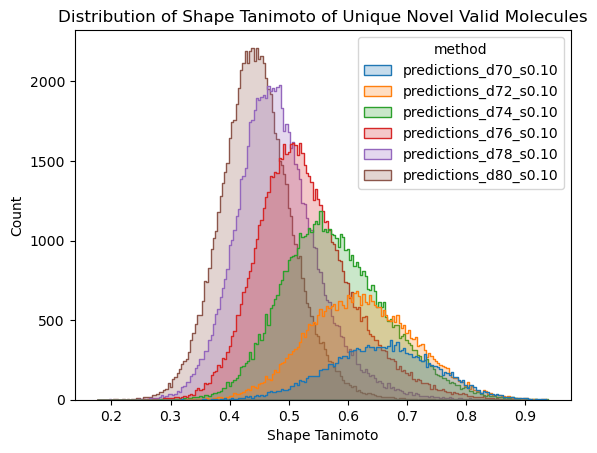

In [25]:
metric = "shape_tanimoto"
metric_name = metrics[metric]
fig = sns.histplot(
    df_best[(df_best.table == "time")].groupby(["table", "method", "smiles_pred"]).agg({metric: "max"}),
    x=metric,
    hue="method",
    # complementary=True,
    # common_norm=False,
    stat="count",
    element="step",
    # fill=False,
    # legend=True, palette="tab10", linewidth=1.5
)
fig.set(
    # xlim=(0, 1),
    # ylim=(0, 2000),
    title=f"Distribution of {metric_name} of Unique Novel Valid Molecules",
    xlabel=metric_name,
)

[(0.0, 1.0),
 Text(0.5, 1.0, 'Distribution of Feature Map Score of Unique Novel Valid Molecules'),
 Text(0.5, 0, 'Feature Map Score')]

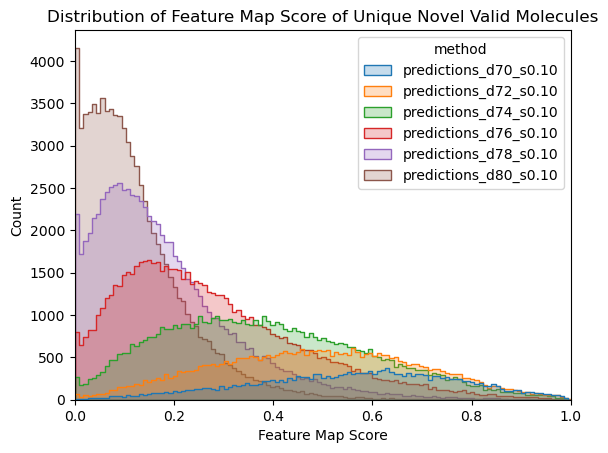

In [26]:
metric = "feat_map_score_1"
metric_name = metrics[metric]
fig = sns.histplot(
    df_best[(df_best.table == "time")].groupby(["table", "method", "smiles_pred"]).agg({metric: "max"}),
    x=metric,
    hue="method",
    # complementary=True,
    # common_norm=False,
    stat="count",
    element="step",
    # fill=False,
    # legend=True, palette="tab10", linewidth=1.5
)
fig.set(
    xlim=(0, 1),
    # ylim=(0, 2000),
    title=f"Distribution of {metric_name} of Unique Novel Valid Molecules",
    xlabel=metric_name,
)

[(-1.0, 1.0),
 Text(0.5, 1.0, 'Distribution of Electrostatic Potential Similarity of Unique Novel Valid Molecules'),
 Text(0.5, 0, 'Electrostatic Potential Similarity')]

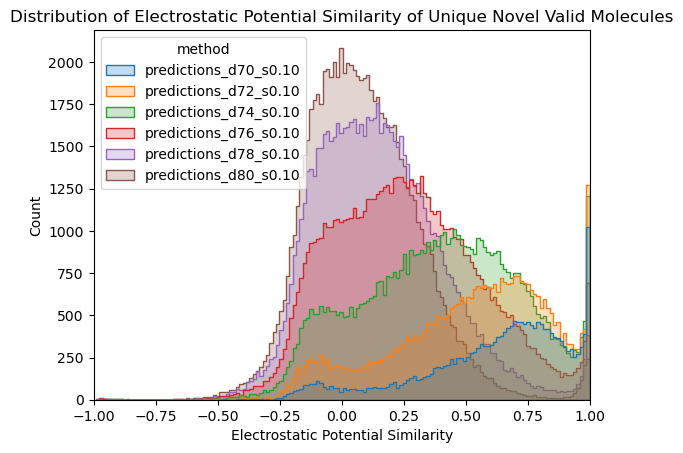

In [27]:
metric = "esp_sim"
metric_name = metrics[metric]
fig = sns.histplot(
    df_best[(df_best.table == "time")].groupby(["table", "method", "smiles_pred"]).agg({metric: "max"}),
    x=metric,
    hue="method",
    # complementary=True,
    # common_norm=False,
    stat="count",
    element="step",
    # fill=False,
    # legend=True, palette="tab10", linewidth=1.5
)
fig.set(
    xlim=(-1, 1),
    # ylim=(0, 2000),
    title=f"Distribution of {metric_name} of Unique Novel Valid Molecules",
    xlabel=metric_name,
)

[Text(0.5, 1.0, 'Distribution of SuCOS of Unique Novel Valid Molecules'),
 Text(0.5, 0, 'SuCOS')]

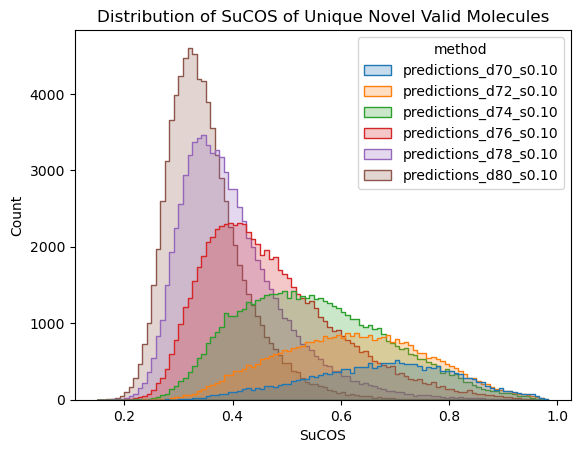

In [28]:
metric = "sucos_1"
metric_name = metrics[metric]
fig = sns.histplot(
    df_best[(df_best.table == "time")].groupby(["table", "method", "smiles_pred"]).agg({metric: "max"}),
    x=metric,
    hue="method",
    # complementary=True,
    # common_norm=False,
    stat="count",
    element="step",
    # fill=False,
    bins=100,
    # legend=True, palette="tab10", linewidth=1.5
)
fig.set(
    # xlim=(0, 1),
    # ylim=(0, 2000),
    title=f"Distribution of {metric_name} of Unique Novel Valid Molecules",
    xlabel=metric_name,
)

[Text(0.5, 1.0, 'Distribution of SuCOS of Unique Novel Valid Molecules'),
 Text(0.5, 0, 'SuCOS')]

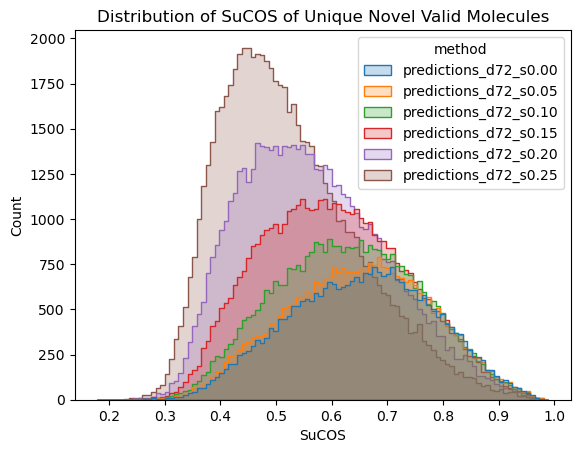

In [29]:
metric = "sucos_2"
metric_name = metrics[metric]
fig = sns.histplot(
    df_best[(df_best.table == "var")].groupby(["table", "method", "smiles_pred"]).agg({metric: "max"}),
    x=metric,
    hue="method",
    # complementary=True,
    # common_norm=False,
    stat="count",
    element="step",
    # fill=False,
    bins=100,
    # legend=True, palette="tab10", linewidth=1.5
)
fig.set(
    # xlim=(0, 1),
    # ylim=(0, 2000),
    title=f"Distribution of {metric_name} of Unique Novel Valid Molecules",
    xlabel=metric_name,
)

[Text(0.5, 1.0, 'Distribution of SuCOS of Unique Novel Valid Molecules'),
 Text(0.5, 0, 'SuCOS')]

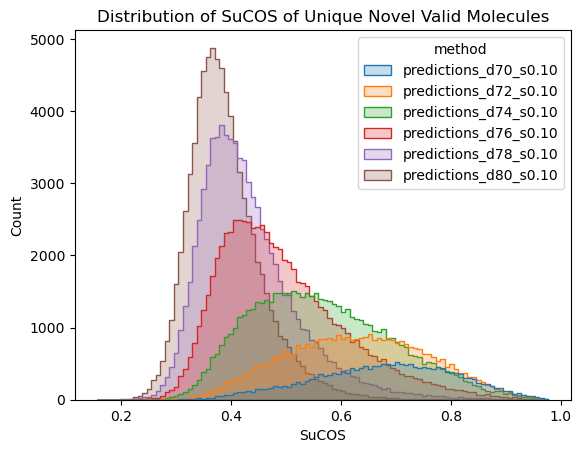

In [30]:
metric = "sucos_2"
metric_name = metrics[metric]
fig = sns.histplot(
    df_best[(df_best.table == "time")].groupby(["table", "method", "smiles_pred"]).agg({metric: "max"}),
    x=metric,
    hue="method",
    # complementary=True,
    # common_norm=False,
    stat="count",
    element="step",
    # fill=False,
    bins=100,
    # legend=True, palette="tab10", linewidth=1.5
)
fig.set(
    # xlim=(0, 1),
    # ylim=(0, 2000),
    title=f"Distribution of {metric_name} of Unique Novel Valid Molecules",
    xlabel=metric_name,
)

[Text(0.5, 1.0, 'Distribution of SuCOS of Unique Novel Valid Molecules'),
 Text(0.5, 0, 'SuCOS')]

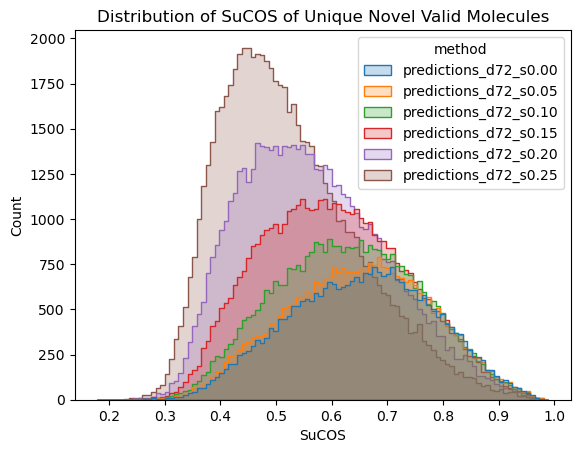

In [31]:
metric = "sucos_2"
metric_name = metrics[metric]
fig = sns.histplot(
    df_best[(df_best.table == "var")].groupby(["table", "method", "smiles_pred"]).agg({metric: "max"}),
    x=metric,
    hue="method",
    # complementary=True,
    # common_norm=False,
    stat="count",
    element="step",
    # fill=False,
    bins=100,
    # legend=True, palette="tab10", linewidth=1.5
)
fig.set(
    # xlim=(0, 1),
    # ylim=(0, 2000),
    title=f"Distribution of {metric_name} of Unique Novel Valid Molecules",
    xlabel=metric_name,
)

[Text(0.5, 1.0, 'Distribution of the best SuCOS of Unique Novel Valid Scaffolds'),
 Text(0.5, 0, 'SuCOS')]

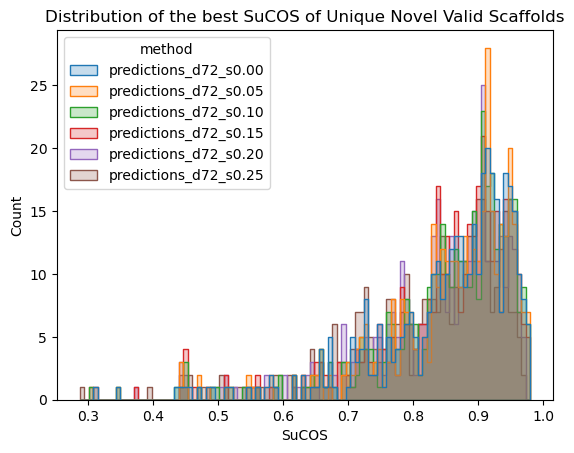

In [32]:
metric = "sucos_2"
metric_name = metrics[metric]
fig = sns.histplot(
    df_best[(df_best.table == "var") & (df_best.scaffold_conserved)].groupby(["table", "method", "scaffold_pred"]).agg({metric: "max"}),
    x=metric,
    hue="method",
    # complementary=True,
    # common_norm=False,
    stat="count",
    element="step",
    # fill=False,
    bins=100,
    # legend=True, palette="tab10", linewidth=1.5
)
fig.set(
    # xlim=(0, 1),
    # ylim=(0, 2000),
    title=f"Distribution of the best {metric_name} of Unique Novel Valid Scaffolds",
    xlabel=metric_name,
)

[(0.5, 1.0),
 Text(0.5, 1.0, 'Out of 100,000 molecules generated, how many\n Unique Novel Molecules have Shape Protrusion larger than x?'),
 Text(0.5, 0, 'Shape Protrusion')]

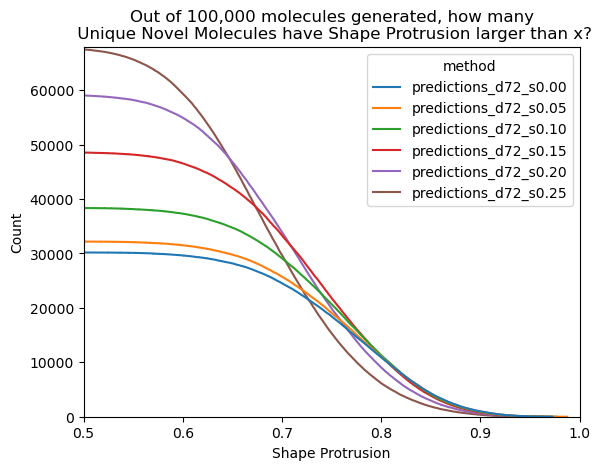

In [33]:
metric = "shape_protrusion_2"
metric_name = metrics[metric]
fig = sns.ecdfplot(
    df_best[df_best.table == "var"].groupby(["table", "method", "smiles_pred"]).agg({metric: "max"}),
    x=metric,
    hue="method",
    complementary=True,
    # common_norm=False,
    stat="count",
    # element="step",
    # fill=False,
    # legend=True, palette="tab10", linewidth=1.5
)
fig.set(
    xlim=(0.5, 1),
    title=f"Out of 100,000 molecules generated, how many\n Unique Novel Molecules have {metric_name} larger than x?",
    xlabel=metric_name,
)

[(0.5, 1.0),
 Text(0.5, 1.0, 'Out of 100,000 molecules generated, how many\n Unique Novel Molecules have SuCOS larger than x?'),
 Text(0.5, 0, 'SuCOS')]

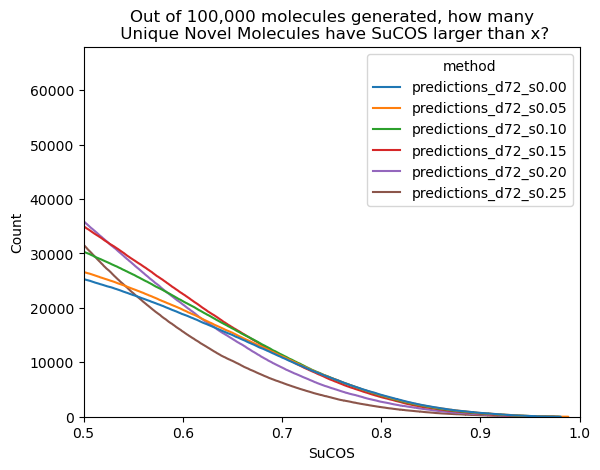

In [34]:
metric = "sucos_1"
metric_name = metrics[metric]
fig = sns.ecdfplot(
    df_best[df_best.table == "var"].groupby(["table", "method", "smiles_pred"]).agg({metric: "max"}),
    x=metric,
    hue="method",
    complementary=True,
    # common_norm=False,
    stat="count",
    # element="step",
    # fill=False,
    # legend=True, palette="tab10", linewidth=1.5
)
fig.set(
    xlim=(0.5, 1),
    title=f"Out of 100,000 molecules generated, how many\n Unique Novel Molecules have {metric_name} larger than x?",
    xlabel=metric_name,
)

[(0.0, 1.0),
 Text(0.5, 1.0, 'Out of 100,000 molecules generated, how many\n Unique Novel Molecules have Electrostatic Potential Similarity larger than x?'),
 Text(0.5, 0, 'Electrostatic Potential Similarity')]

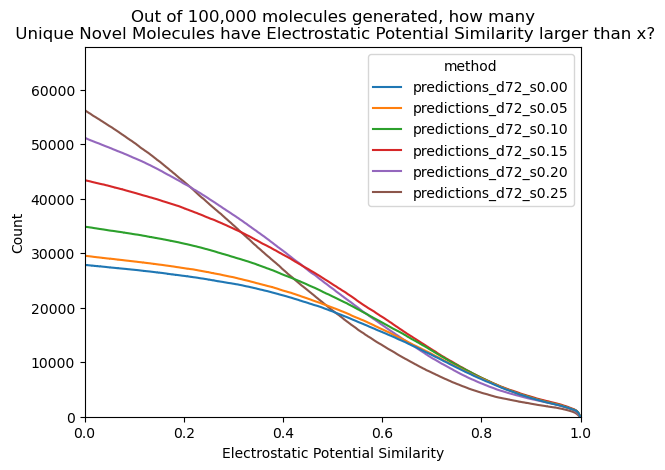

In [35]:
metric = "esp_sim"
metric_name = metrics[metric]
fig = sns.ecdfplot(
    df_best[df_best.table == "var"].groupby(["table", "method", "smiles_pred"]).agg({metric: "max"}),
    x=metric,
    hue="method",
    complementary=True,
    # common_norm=False,
    stat="count",
    # element="step",
    # fill=False,
    # legend=True, palette="tab10", linewidth=1.5
)
fig.set(
    xlim=(0.0, 1),
    title=f"Out of 100,000 molecules generated, how many\n Unique Novel Molecules have {metric_name} larger than x?",
    xlabel=metric_name,
)

In [36]:
# how many interesting new molecules have we created?

metric = "sucos_1"
metric_name = metrics[metric]
fig = sns.ecdfplot(
    df_best[df_best.table == "var"].groupby(["table", "method", "smiles"]).agg({metric: "max"}),
    x=metric,
    hue="method",
    complementary=True,
    # common_norm=False,
    stat="count",
    # element="step",
    # fill=False,
    # legend=True, palette="tab10", linewidth=1.5
)
fig.set(
    xlim=(0.5, 1),
    title=f"Out of 100,000 molecules generated, how many\n Unique Novel Molecules have {metric_name} larger than x?",
    xlabel=metric_name,
)

KeyError: 'smiles'

In [ ]:
# how many interesting new molecules have we created?

metric = "sucos_1"
metric_name = metrics[metric]
fig = sns.ecdfplot(
    df_best[(df_best.table == "var") & (~df_best.scaffold_conserved)].groupby(["table", "method", "smiles"]).agg({metric: "max"}),
    x=metric,
    hue="method",
    complementary=True,
    # common_norm=False,
    stat="count",
    # element="step",
    # fill=False,
    # legend=True, palette="tab10", linewidth=1.5
)
fig.set(
    xlim=(0.5, 1),
    title="Out of 100,00 generated molecules, how many Unique Novel\n Valid Molecules have a new scaffold and SuCOS larger than x?",
    xlabel=metric_name,
)

In [ ]:
# how many interesting new molecules have we created?

metric = "sucos_1"
metric_name = metrics[metric]

fig = sns.histplot(
    df_best[(df_best.table == "time")].groupby(["table", "method", "smiles"]).agg({metric: "max"}),
    x=metric,
    hue="method",
    # complementary=True,
    # common_norm=False,
    stat="count",
    element="step",
    fill=False,
    # legend=True, palette="tab10", linewidth=1.5
)
fig.set(
    xlim=(0, 1),
    # ylim=(0, 2000),
    title=f"Distribution of {metric_name} of Unique Novel Valid Molecules",
    xlabel=metric_name,
)

In [ ]:
# how many interesting new molecules have we created?

metric = "sucos_1"
metric_name = metrics[metric]

fig = sns.histplot(
    df_best[(df_best.table == "time") & (~df_best.scaffold_conserved)].groupby(["table", "method", "smiles"]).agg({metric: "max"}),
    x=metric,
    hue="method",
    # complementary=True,
    # common_norm=False,
    stat="count",
    element="step",
    fill=False,
    # legend=True, palette="tab10", linewidth=1.5
)
fig.set(
    xlim=(0, 1),
    # ylim=(0, 2000),
    title=f"Distribution of {metric_name} of Unique Novel Valid Molecules with new Scaffolds",
    xlabel="SuCOS",
)

In [ ]:
# how many interesting new molecules have we created?
metric = "shape_sim"
metric_name = metrics[metric]

fig = sns.histplot(
    df_best[(df_best.table == "var") & (~df_best.scaffold_conserved)].groupby(["table", "method", "smiles"]).agg({metric: "max"}),
    x=metric,
    hue="method",
    # complementary=True,
    # common_norm=False,
    stat="count",
    element="step",
    fill=False,
    bins=100,
    # legend=True, palette="tab10", linewidth=1.5
)
fig.set(
    # xlim=(-1, 1),
    # ylim=(0, 2000),
    title=f"Distribution of {metric_name} of Unique Novel Valid Scaffold Hops",
    xlabel=metric_name,
)

In [ ]:
# how many interesting new molecules have we created?
metric = "esp_sim_1"
metric_name = metrics[metric]

fig = sns.histplot(
    df_best[(df_best.table == "var") & (~df_best.scaffold_conserved)].groupby(["table", "method", "smiles"]).agg({metric: "max"}),
    x=metric,
    hue="method",
    # complementary=True,
    # common_norm=False,
    stat="count",
    element="step",
    cumulative=True,
    fill=False,
    # bins=100,
    bins=10000,
    # legend=True, palette="tab10", linewidth=1.5
)
fig.set(
    # xlim=(-1, 1),
    # ylim=(0, 2000),
    title=f"Distribution of {metric_name} of Unique Novel Valid Scaffold Hops",
    xlabel=metric_name,
)

In [ ]:
# how many interesting new molecules have we created?
metric = "sucos_1"
metric_name = metrics[metric]

fig = sns.histplot(
    df_best[(df_best.table == "var") & (~df_best.scaffold_conserved)].groupby(["table", "method", "smiles"]).agg({metric: "max"}),
    x=metric,
    hue="method",
    # complementary=True,
    # common_norm=False,
    stat="count",
    element="step",
    fill=False,
    bins=100,
    # legend=True, palette="tab10", linewidth=1.5
)
fig.set(
    # xlim=(-1, 1),
    # ylim=(0, 2000),
    title=f"Distribution of {metric_name} of Unique Novel Valid Scaffold Hops",
    xlabel=metric_name,
)

In [ ]:
# how many interesting new molecules have we created?

df_plot = (
    df_best[df_best.table == "time"].groupby(["table", "method", "smiles", "scaffold_conserved"]).agg({"sucos_1": "max"})
).reset_index()
df_plot_all = df_plot.copy()
df_plot_all["subset"] = "All"
df_plot_scaffold_hop = df_plot[~df_plot.scaffold_conserved].copy()
df_plot_scaffold_hop["subset"] = "Scaffold Hop"
df_plot = pd.concat([df_plot_all, df_plot_scaffold_hop], ignore_index=True).reset_index(drop=True)


In [78]:
def ecdf(s: pd.Series) -> pd.Series:
    sq = s.value_counts()
    return sq.sort_index(ascending=False).cumsum() * 1.0 / sum(sq)

# Appendix

## Old tables

In [ ]:
cols = [
    "table",
    "method",
    "scaffold_conserved",
]
df_scaff = df[df.valid_novel][cols].groupby(["table", "integration steps", "sigma"]).mean()
df_scaff.style.format("{:.2%}")

# Old plots

In [ ]:
metric = "sucos"
# metric = "tanimoto"
name = metrics[metric]
sns.histplot(
    df[df.valid_novel][df.table == "table 1"][["method", metric]].reset_index(drop=True),
    x=metric,
    hue="method",
    bins=100,
    # cumulative=True,
    common_norm=False,
    stat="density",
    element="step",
    # kde=True,
    fill=False,
    # legend=True, palette="tab10", linewidth=1.5
)

In [ ]:
metric = "sucos"
# metric = "tanimoto"
name = metrics[metric]
sns.histplot(
    df[(df.valid_novel & (df.table == "table 2"))][["method", metric]].reset_index(drop=True),
    x=metric,
    hue="method",
    bins=100,
    # cumulative=True,
    common_norm=False,
    stat="density",
    element="step",
    # kde=True,
    fill=False,
    # legend=True, palette="tab10", linewidth=1.5
)

In [ ]:
# metric = "sucos"
metric = "tanimoto"
name = metrics[metric]
sns.histplot(
    df[(df.valid_novel & (df.table == "table 1"))][["method", metric]].reset_index(drop=True),
    x=metric,
    hue="method",
    bins=100,
    cumulative=True,
    common_norm=False,
    stat="density",
    element="step",
    # kde=True,
    fill=False,
    # legend=True, palette="tab10", linewidth=1.5
)

In [ ]:
# metric = "sucos"
metric = "tanimoto"
name = metrics[metric]
sns.histplot(
    df[(df.valid_novel & (df.table == "table 2"))][["method", metric]].reset_index(drop=True),
    x=metric,
    hue="method",
    bins=100,
    cumulative=True,
    common_norm=False,
    stat="density",
    element="step",
    # kde=True,
    fill=False,
    # legend=True, palette="tab10", linewidth=1.5
)

## Old code 

In [ ]:
# How much repetition is there? How unique are the generated molecules?
s = df.groupby(["table", "integration steps", "sigma"])["smiles_pred"].agg(compute_uniqueness)
s.name = "Uniqueness"
s

In [ ]:
# How many of the valid generated molecules are not in the test set?
s = df.groupby(["table", "integration steps", "sigma"])["smiles_pred"].agg(compute_novelty)
s.name = "Novelty"
s

In [ ]:
# How many of the valid generated molecules are in the test set?
s = (df.groupby(["table", "integration steps", "sigma"])["smiles_pred"].agg(compute_novelty) - 1).abs()
s.name = "In Test Set"
s

In [ ]:
# How many valid, unique and new molecules have we generated?
s = df.groupby(["table", "integration steps", "sigma"])["smiles_pred"].agg(compute_unique_novelty)
s.name = "Unique Novelty"
s